# 전기차 가격 예측 — 원본 작업 유지

원본의 두 분포 그래프 → 모델별 배터리 중앙값 → 이상치 처리 → 표준화 → 원핫 인코딩 → OLS → 주행거리 제거 → Random Forest/XGBoost/LightGBM → LightGBM 제출 순서를 유지했습니다.
8:2 분리와 기존 분리 seed를 유지하되 전처리 전에 분리하고, XGBoost/LightGBM 평가에 각 모델의 예측값을 사용하도록 수정했습니다. OLS 공선성과 최신 pandas 호환 오류도 보완했습니다.
새 모델·교차검증·다른 모델 선택 방법은 추가하지 않았습니다. OLS p-value로 트리 모델 특징을 제거하는 기존 접근은 유지했으므로 최적 특징 선택을 보장하지 않습니다.
이 검증 점수는 대회 순위와 다르며, 기존 최종 상위 5.6% 기록을 재검증한 결과가 아닙니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import font_manager
from sklearn.model_selection import train_test_split
from IPython.display import display
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
display(train.head())
display(test.head())

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년),가격(백만원)
0,TRAIN_0000,P사,TayGTS,Nearly New,86.077,AWD,13642,0,No,2,159.66
1,TRAIN_0001,K사,Niro,Nearly New,56.000,FWD,10199,6,No,0,28.01
2,TRAIN_0002,A사,eT,Brand New,91.200,AWD,2361,7,No,0,66.27
3,TRAIN_0003,A사,RSeTGT,Nearly New,NaN,AWD,21683,3,No,0,99.16
4,TRAIN_0004,B사,i5,Pre-Owned,61.018,AWD,178205,1,No,0,62.02


,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년)
0,TEST_000,P사,TayCT,Nearly New,76.093,AWD,14057,2,No,0
1,TEST_001,B사,iX,Brand New,90.000,AWD,7547,8,No,0
2,TEST_002,B사,i5,Brand New,NaN,RWD,7197,7,Yes,0
3,TEST_003,H사,ION5,Nearly New,68.479,AWD,10357,7,No,1
4,TEST_004,K사,EV6,Brand New,NaN,FWD,7597,10,No,0


In [3]:
# test.shape

In [4]:
# train.describe()

In [5]:
train.shape

(7497, 11)

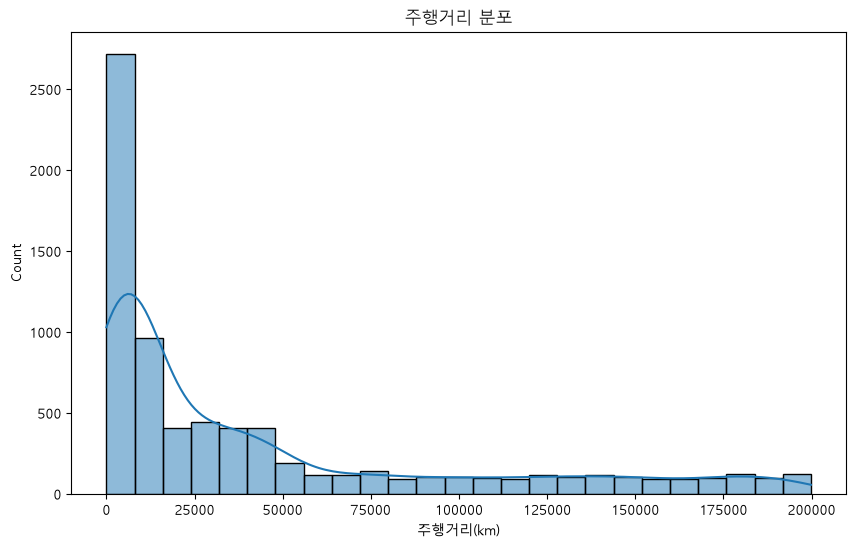

In [6]:

plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='주행거리(km)', kde=True, bins=25)

plt.xlabel('주행거리(km)')
plt.title('주행거리 분포')
plt.show() 


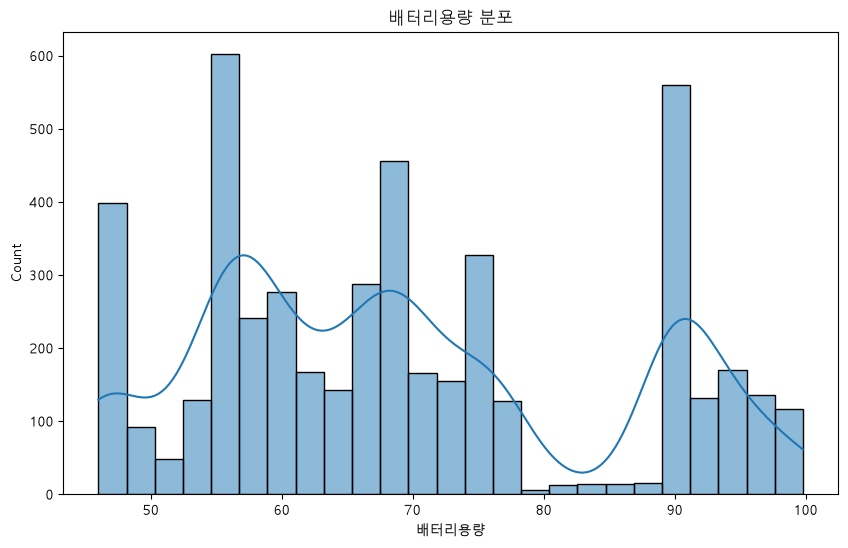

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='배터리용량', kde=True, bins=25)

plt.xlabel('배터리용량')
plt.title('배터리용량 분포')
plt.show() 


In [8]:
# 기존 8:2 분리와 random_state=3000 유지. 전처리 전에 분리해 검증 정보 유입 방지.
train, validation = train_test_split(train, test_size=0.2, random_state=3000)
train, validation = train.copy(), validation.copy()
# 기존 모델별 중앙값 대체 유지. 검증/제출 자료에는 학습 데이터 기준을 적용.
battery_by_model = train.groupby('모델')['배터리용량'].median()
battery_median = train['배터리용량'].median()
for frame in [train, validation, test]:
    frame['배터리용량'] = frame['배터리용량'].fillna(frame['모델'].map(battery_by_model))


In [9]:
for frame in [train, validation, test]:
    frame['배터리용량'] = frame['배터리용량'].fillna(battery_median)

In [10]:
#아웃라이어 제거

def is_outliers(s):
    lower_limit = s.mean() - (s.std()*3)
    upper_limit = s.mean() + (s.std()*3)
    return ~s.between(lower_limit, upper_limit)

In [11]:
# 기존 3표준편차 이상치 기준 유지. 검증 대상은 제거하지 않는다.
for group in ['차량상태', '구동방식', '사고이력']:
    price_group = train.groupby(group)['가격(백만원)']
    means = price_group.transform('mean')
    stds = price_group.transform('std').fillna(0)
    train = train.loc[(train['가격(백만원)']-means).abs().le(3*stds)].copy()


In [12]:
train.shape

(5997, 11)

In [13]:
# train.head()
train_id = train.pop('ID')
test_id = test.pop('ID')
y_train = train.pop('가격(백만원)')
validation_id = validation.pop('ID')
y_val = validation.pop('가격(백만원)')

In [14]:
train.isnull().sum()

제조사         0
모델          0
차량상태        0
배터리용량       0
구동방식        0
주행거리(km)    0
보증기간(년)     0
사고이력        0
연식(년)       0
dtype: int64

In [15]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
col = train.select_dtypes(include = ['number']).columns
train[col] = scaler.fit_transform(train[col]) 
test[col] = scaler.transform(test[col]) 
validation[col] = scaler.transform(validation[col])

In [16]:
# 기존 원핫 인코딩 유지. 숫자 dtype과 학습 열 순서를 통일.
col = ['모델', '제조사', '차량상태', '구동방식', '사고이력']
train = pd.get_dummies(train, columns=col, dtype=float)
test = pd.get_dummies(test, columns=col, dtype=float).reindex(columns=train.columns, fill_value=0)
validation = pd.get_dummies(validation, columns=col, dtype=float).reindex(columns=train.columns, fill_value=0)


In [17]:
train.head()

,배터리용량,주행거리(km),보증기간(년),연식(년),모델_EV6,모델_ID4,모델_ION5,모델_ION6,모델_IONIQ,모델_KNE,...,제조사_T사,제조사_V사,차량상태_Brand New,차량상태_Nearly New,차량상태_Pre-Owned,구동방식_AWD,구동방식_FWD,구동방식_RWD,사고이력_No,사고이력_Yes
5049,-0.827948,-0.353315,0.963814,3.137178,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3896,1.260593,-0.643344,1.282166,-0.388289,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3376,-1.702067,2.379691,-1.264648,-0.388289,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2489,-0.155626,-0.587685,-0.309593,-0.388289,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
6821,1.406033,-0.334104,0.327111,3.137178,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [18]:
print(train.shape, test.shape)

(5997, 40) (846, 40)


In [19]:
# 선형 회귀
import statsmodels.api as sm
# OLS의 완전 공선성 제거: 제조사는 모델에 종속되므로 OLS에서만 제외.
# 트리 모델의 기존 제조사/모델 특징은 유지한다.
ols_columns = [name for name in train if not name.startswith('제조사_')]
for prefix in ['모델_', '차량상태_', '구동방식_', '사고이력_']:
    reference = next(name for name in ols_columns if name.startswith(prefix))
    ols_columns.remove(reference)
X = train[ols_columns]
y = y_train

# 상수항 추가 (절편 포함)
X = sm.add_constant(X)

# OLS 모델 생성
model = sm.OLS(y, X)

# 모델 학습
results = model.fit()

# 결과 요약 출력
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                가격(백만원)   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 2.037e+04
Date:                Sat, 10 Oct 2026   Prob (F-statistic):               0.00
Time:                        01:18:20   Log-Likelihood:                -16298.
No. Observations:                5997   AIC:                         3.266e+04
Df Residuals:                    5967   BIC:                         3.286e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              43.1472      0.362    1

In [20]:
# 유의하지않은 변수 삭제
train.drop(columns=['주행거리(km)'], inplace=True)
test.drop(columns=['주행거리(km)'], inplace=True)

validation.drop(columns=['주행거리(km)'], inplace=True)

In [21]:
# 앞에서 분리한 동일 검증 세트 사용
X_tr, X_val, y_tr = train, validation, y_train

In [22]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=3000, n_jobs=4)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)

In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_val, pred))
print("RMSE:", rmse)
rf_rmse = float(rmse)

RMSE: 1.3677186078910624


In [24]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=5024, n_jobs=4)
model.fit(X_tr, y_tr)
predictions = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, predictions))
print("RMSE:", rmse)
xgb_rmse = float(rmse)

RMSE: 1.4009418755041476


In [25]:
import lightgbm as lgb
model = lgb.LGBMRegressor(random_state=3000, n_jobs=4, verbosity=-1)

# 모델 학습
model.fit(X_tr, y_tr)

# 예측
predictions = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, predictions))
print("RMSE:", rmse)
lgb_rmse = float(rmse)
comparison = pd.DataFrame({'모델': ['Random Forest', 'XGBoost', 'LightGBM'],
                           '검증 RMSE(백만원)': [rf_rmse, xgb_rmse, lgb_rmse]})
display(comparison)
comparison.to_csv('model_comparison.csv', index=False)


RMSE: 1.3441522938124364


,모델,검증 RMSE(백만원)
0,Random Forest,1.367719
1,XGBoost,1.400942
2,LightGBM,1.344152


In [26]:
# 기존 최종 LightGBM 제출 흐름 유지. 모델 비교 후 더 좋은 모델로 임의 변경하지 않음.
# 제출 전 학습/검증 전체를 재학습한다. 성능 표는 위 검증 단계의 결과이다.
model.fit(pd.concat([X_tr, X_val]), pd.concat([y_tr, y_val]))
pred = model.predict(test)
sub = pd.DataFrame({'ID': test_id, '가격(백만원)': pred})
sample = pd.read_csv('sample_submission.csv')
assert sample['ID'].tolist() == sub['ID'].tolist()
assert len(sub) == len(test) and np.isfinite(pred).all()
sub.to_csv('result13.csv', index=False)
